# PHEMS Pediatric Sepsis — Data Exploration

Goal: get a clear picture of the data before deciding on features or models.

**The task:** at every (patient, hour) row in the test set, predict the probability that the patient currently has sepsis. The submission key is `person_id_datetime` (e.g. `1416048048_2021-03-25 10:00:00`) and the value is a float probability.

Sections:
1. Foundations — sizes, patients, class balance, demographics
2. Temporal structure — stay lengths, when sepsis turns positive, lead time
3. Per-table content — what features exist, missingness, value distributions
4. Value distributions — what do the actual measurements look like?
5. Sepsis timing patterns — where in stays do positives appear?
6. Train vs test consistency — same population?

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

ROOT = Path('phems-hackathon-early-sepsis-prediction')
TRAIN = ROOT / 'training_data'
TEST = ROOT / 'testing_data'

## 1. Foundations

Load the labels and demographics, get the basic shape of the problem.

In [17]:
y_train = pd.read_csv(TRAIN / 'SepsisLabel_train.csv')
y_test = pd.read_csv(TEST / 'SepsisLabel_test.csv')
sub_sample = pd.read_csv(ROOT / 'SepsisLabel_sample_submission.csv')

y_train['measurement_datetime'] = pd.to_datetime(y_train['measurement_datetime'])
y_test['measurement_datetime'] = pd.to_datetime(y_test['measurement_datetime'])

print('Train labels:', y_train.shape)
print('Test rows:   ', y_test.shape)
print('Submission:  ', sub_sample.shape)
y_train.head()

Train labels: (331653, 3)
Test rows:    (130483, 2)
Submission:   (130483, 2)


,person_id,measurement_datetime,SepsisLabel
0,274096387,2024-12-03 20:00:00,0
1,1719359031,2024-04-20 09:00:00,0
2,2024544816,2021-07-14 07:00:00,0
3,213710896,2022-05-24 07:00:00,0
4,1335786468,2024-08-25 22:00:00,0


In [18]:
# Sample rows from each label / submission file to see the raw structure
print('=== y_train.head() ===')
print(y_train.head())
print()
print('=== y_test.head() ===')
print(y_test.head())
print()
print('=== sub_sample.head() ===')
print(sub_sample.head())

=== y_train.head() ===
    person_id measurement_datetime  SepsisLabel
0   274096387  2024-12-03 20:00:00            0
1  1719359031  2024-04-20 09:00:00            0
2  2024544816  2021-07-14 07:00:00            0
3   213710896  2022-05-24 07:00:00            0
4  1335786468  2024-08-25 22:00:00            0

=== y_test.head() ===
    person_id measurement_datetime
0  1416048048  2021-03-25 10:00:00
1   280531880  2024-01-22 18:00:00
2  1127023302  2023-12-29 21:00:00
3  2065909112  2021-07-07 05:00:00
4   264445818  2024-08-23 22:00:00

=== sub_sample.head() ===
               person_id_datetime  SepsisLabel
0  1416048048_2021-03-25 10:00:00          0.5
1   280531880_2024-01-22 18:00:00          0.5
2  1127023302_2023-12-29 21:00:00          0.5
3  2065909112_2021-07-07 05:00:00          0.5
4   264445818_2024-08-23 22:00:00          0.5


In [19]:
# Confirm the submission format we have to produce
print('Sample submission columns:', sub_sample.columns.tolist())
print('Sample submission rows:   ', len(sub_sample))
print('Sample value distribution:', sub_sample['SepsisLabel'].value_counts().head().to_dict())
print()
print('First 3 keys:')
print(sub_sample.head(3).to_string(index=False))

Sample submission columns: ['person_id_datetime', 'SepsisLabel']
Sample submission rows:    130483
Sample value distribution: {0.5: 130483}

First 3 keys:
            person_id_datetime  SepsisLabel
1416048048_2021-03-25 10:00:00          0.5
 280531880_2024-01-22 18:00:00          0.5
1127023302_2023-12-29 21:00:00          0.5


In [20]:
# Class balance — both at the (person, hour) level and at the patient level
hour_pos = y_train['SepsisLabel'].mean()
patient_max = y_train.groupby('person_id')['SepsisLabel'].max()
patient_pos = patient_max.mean()

print(f'Hour-level positive rate:    {hour_pos:.4f}  ({y_train.SepsisLabel.sum():,} / {len(y_train):,})')
print(f'Patient-level positive rate: {patient_pos:.4f}  ({patient_max.sum():.0f} / {patient_max.size:,})')
print()
print('This is a SEVERELY imbalanced problem at the hour level.')
print('Class weighting / scale_pos_weight / threshold tuning will matter.')

Hour-level positive rate:    0.0207  (6,874 / 331,653)
Patient-level positive rate: 0.0366  (97 / 2,649)

This is a SEVERELY imbalanced problem at the hour level.
Class weighting / scale_pos_weight / threshold tuning will matter.


In [21]:
print(f'Unique train patients: {y_train.person_id.nunique():,}')
print(f'Unique test patients:  {y_test.person_id.nunique():,}')
print(f'Patient overlap:       {len(set(y_train.person_id) & set(y_test.person_id))}')
print()
print('No patient overlap means we can split train however we want without leakage')
print('between train/val patients.')

Unique train patients: 2,649
Unique test patients:  1,138
Patient overlap:       18

No patient overlap means we can split train however we want without leakage
between train/val patients.


In [22]:
demo_tr = pd.read_csv(TRAIN / 'person_demographics_episode_train.csv')
demo_te = pd.read_csv(TEST / 'person_demographics_episode_test.csv')

print(f'Demographics rows (train): {len(demo_tr):,}')
print(f'Unique persons in demo:    {demo_tr.person_id.nunique():,}')
print(f'  -> implies multiple visits per patient (visit-level rows)')
print()
print('Gender (train):', demo_tr.gender.value_counts(dropna=False).to_dict())
print()
print('Age in months (train):')
print(demo_tr.age_in_months.describe().round(1))
print()
print(f'Age in years — median: {demo_tr.age_in_months.median()/12:.1f}y, max: {demo_tr.age_in_months.max()/12:.1f}y')

Demographics rows (train): 3,391
Unique persons in demo:    2,649
  -> implies multiple visits per patient (visit-level rows)

Gender (train): {'MALE': 1952, 'FEMALE': 1439}

Age in months (train):
count    3391.0
mean       69.2
std        69.5
min         0.0
25%         7.0
50%        43.0
75%       127.0
max       256.0
Name: age_in_months, dtype: float64

Age in years — median: 3.6y, max: 21.3y


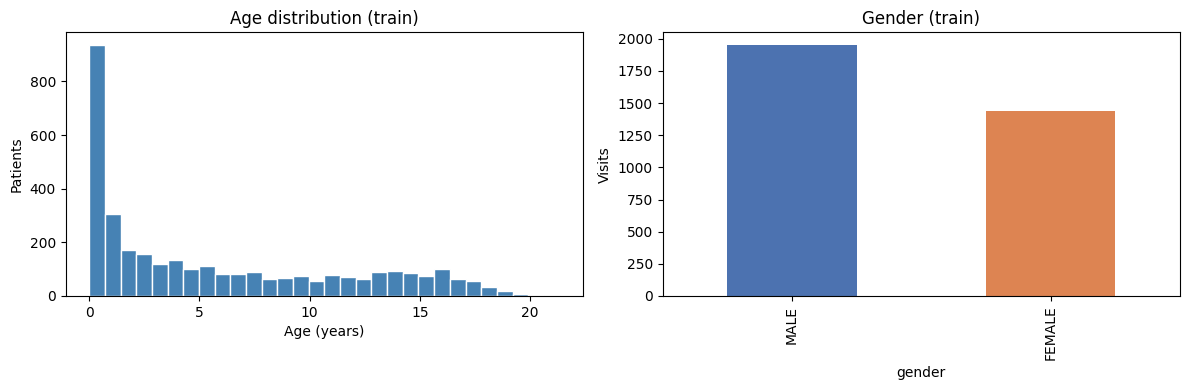

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(demo_tr.age_in_months / 12, bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Age (years)'); axes[0].set_ylabel('Patients'); axes[0].set_title('Age distribution (train)')
demo_tr.gender.value_counts().plot.bar(ax=axes[1], color=['#4c72b0', '#dd8452'])
axes[1].set_title('Gender (train)'); axes[1].set_ylabel('Visits')
plt.tight_layout(); plt.show()

## 2. Temporal structure

How long are the stays, when do positive labels appear, and how much lead time exists before sepsis onset?

In [24]:
hours_per_pt = y_train.groupby('person_id').size()
print('Hours per patient (train):')
print(hours_per_pt.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(1))
print()
print(f'Long tail: max stay is {hours_per_pt.max():,} hours = {hours_per_pt.max()/24:.0f} days')

Hours per patient (train):
count    2649.0
mean      125.2
std       265.8
min         1.0
25%        27.0
50%        55.0
75%       125.0
90%       269.0
95%       450.0
99%      1106.6
max      5792.0
dtype: float64

Long tail: max stay is 5,792 hours = 241 days


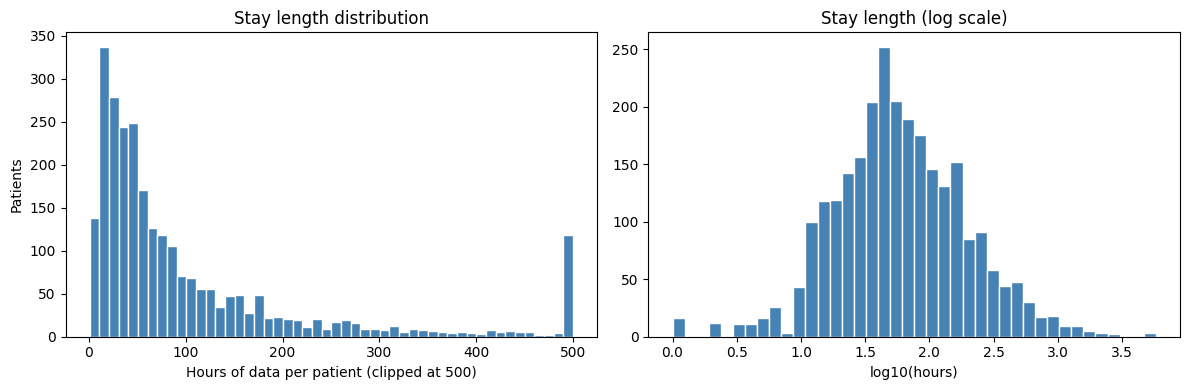

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(hours_per_pt.clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Hours of data per patient (clipped at 500)'); axes[0].set_ylabel('Patients')
axes[0].set_title('Stay length distribution')
axes[1].hist(np.log10(hours_per_pt), bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('log10(hours)'); axes[1].set_title('Stay length (log scale)')
plt.tight_layout(); plt.show()

In [26]:
# For patients who go septic, how many hours into their stay does the first positive label appear?
y_train_sorted = y_train.sort_values(['person_id', 'measurement_datetime'])
y_train_sorted['hour_index'] = y_train_sorted.groupby('person_id').cumcount()

septic_pts = y_train_sorted[y_train_sorted.SepsisLabel == 1].groupby('person_id').agg(
    first_pos_hour=('hour_index', 'min'),
    n_pos_hours=('hour_index', 'count'),
)
septic_pts['stay_length'] = hours_per_pt.loc[septic_pts.index].values
septic_pts['lead_time'] = septic_pts['first_pos_hour']
septic_pts['septic_fraction'] = septic_pts['n_pos_hours'] / septic_pts['stay_length']

print(f'Septic patients in train: {len(septic_pts)}')
print()
print('Hours of healthy data BEFORE first positive label (lead time):')
print(septic_pts['lead_time'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(1))
print()
print('Fraction of stay that is septic:')
print(septic_pts['septic_fraction'].describe(percentiles=[0.25, 0.5, 0.75]).round(3))

Septic patients in train: 97

Hours of healthy data BEFORE first positive label (lead time):
count      97.0
mean      106.9
std       188.5
min         0.0
10%         0.0
25%         6.0
50%        40.0
75%       116.0
90%       324.4
max      1416.0
Name: lead_time, dtype: float64

Fraction of stay that is septic:
count    97.000
mean      0.156
std       0.123
min       0.009
25%       0.066
50%       0.129
75%       0.204
max       0.649
Name: septic_fraction, dtype: float64


## 3. Per-table content & missingness

What features actually exist, how sparse are they, and what value ranges do they cover?

In [27]:
# Vitals are the most clinically-direct signal for sepsis. Look at them carefully.
vitals = pd.read_csv(TRAIN / 'measurement_meds_train.csv')
vitals['measurement_datetime'] = pd.to_datetime(vitals['measurement_datetime'])
print('Vitals shape:', vitals.shape)
print('Columns:', vitals.columns.tolist())
print()
vitals_cols = [c for c in vitals.columns if c not in ('visit_occurrence_id', 'person_id', 'measurement_datetime')]
print('Numeric summary (within vitals table):')
print(vitals[vitals_cols].describe().round(2))
print()
print('Missingness per vital column (within vitals table):')
print(vitals[vitals_cols].isna().mean().round(3).sort_values().to_string())
print()
print(f'Unique patients with vitals: {vitals.person_id.nunique()}')
print(f'Vital records per patient — median: {int(vitals.groupby("person_id").size().median())}')

Vitals shape: (257749, 10)
Columns: ['visit_occurrence_id', 'person_id', 'measurement_datetime', 'Systolic blood pressure', 'Diastolic blood pressure', 'Body temperature', 'Respiratory rate', 'Heart rate', 'Measurement of oxygen saturation at periphery', 'Oxygen/Gas total [Pure volume fraction] Inhaled gas']

Numeric summary (within vitals table):
       Systolic blood pressure  Diastolic blood pressure  Body temperature  Respiratory rate  Heart rate  Measurement of oxygen saturation at periphery  \
count                 40095.00                  40082.00         204136.00          83304.00    96973.00                                       96817.00   
mean                    236.85                    133.97             37.87            478.17     1697.48                                        1246.62   
std                    3767.82                   2082.88            217.40           3995.04    13910.36                                       10468.13   
min                      25.00

In [28]:
# DATA QUALITY ALERT: vitals contain extreme outliers (likely sensor errors / unit confusions).
# Medians look clinically plausible, but the maxima are absurd — SBP up to ~138,000, HR up to ~215,000.
# These need to be CLIPPED before training (proposal didn't anticipate this).
print('Vital sign value ranges (raw — no clipping):')
for c in vitals_cols:
    s = vitals[c].dropna()
    if len(s) == 0:
        continue
    print(f'  {c[:40]:40s}  min={s.min():>8.1f}  median={s.median():>7.1f}  max={s.max():>10.0f}  p99.5={s.quantile(0.995):>10.1f}')
print()
print('Plausible clinical ranges (for clipping):')
print('  HR:  30-250 bpm')
print('  RR:  5-100 breaths/min')
print('  SBP: 30-220 mmHg')
print('  DBP: 15-150 mmHg')
print('  Temp: 30-43 °C')
print('  SpO2: 50-100 %')

Vital sign value ranges (raw — no clipping):
  Systolic blood pressure                   min=    25.0  median=   99.0  max=    138375  p99.5=     163.0
  Diastolic blood pressure                  min=    10.0  median=   54.5  max=     89125  p99.5=     114.0
  Body temperature                          min=     0.0  median=   36.4  max=     39425  p99.5=      38.6
  Respiratory rate                          min=     0.0  median=   31.5  max=     78375  p99.5=   34899.3
  Heart rate                                min=     0.0  median=  120.8  max=    215775  p99.5=  125939.0
  Measurement of oxygen saturation at peri  min=    43.5  median=   97.2  max=     99992  p99.5=   97675.0
  Oxygen/Gas total [Pure volume fraction]   min=     0.0  median=    0.1  max=     23375  p99.5=    5672.3

Plausible clinical ranges (for clipping):
  HR:  30-250 bpm
  RR:  5-100 breaths/min
  SBP: 30-220 mmHg
  DBP: 15-150 mmHg
  Temp: 30-43 °C
  SpO2: 50-100 %


In [29]:
labs = pd.read_csv(TRAIN / 'measurement_lab_train.csv')
labs['measurement_datetime'] = pd.to_datetime(labs['measurement_datetime'])
lab_cols = [c for c in labs.columns if c not in ('visit_occurrence_id', 'person_id', 'measurement_datetime')]
print(f'Lab table: {labs.shape}, {len(lab_cols)} lab measurements')
print()
print('Missingness rate per lab column (sorted):')
miss = labs[lab_cols].isna().mean().sort_values()
print(miss.round(3).to_string())

Lab table: (69307, 40), 37 lab measurements

Missingness rate per lab column (sorted):
Chloride [Moles/volume] in Blood                       0.523
Sodium [Moles/volume] in Serum or Plasma               0.524
Potassium [Moles/volume] in Blood                      0.536
Hematocrit [Volume Fraction] of Blood                  0.594
Blood arterial pH                                      0.604
Creatinine [Mass/volume] in Blood                      0.621
 activated                                             0.637
Total white blood count                                0.638
Hemoglobin [Moles/volume] in Blood                     0.638
Neutrophil Ab [Units/volume] in Serum                  0.639
C reactive protein [Mass/volume] in Serum or Plasma    0.664
White blood cell count                                 0.682
Bicarbonate [Moles/volume] in Venous blood             0.685
Oxygen [Partial pressure] in Venous blood              0.686
Lactate [Moles/volume] in Blood                        0.70

In [30]:
# measurement_observation — wide format: neuro / perfusion metrics (Glasgow coma, pupil response, capillary refill)
m_obs = pd.read_csv(TRAIN / 'measurement_observation_train.csv')
m_obs['measurement_datetime'] = pd.to_datetime(m_obs['measurement_datetime'])
m_obs_cols = [c for c in m_obs.columns if c not in ('visit_occurrence_id', 'person_id', 'measurement_datetime')]
print('measurement_observation shape:', m_obs.shape)
print('Columns:', m_obs_cols)
print()
print('Numeric summary:')
print(m_obs[m_obs_cols].describe(include='all').round(2))
print()
print('Missingness per column (within table):')
print(m_obs[m_obs_cols].isna().mean().round(3).sort_values().to_string())

measurement_observation shape: (50553, 11)
Columns: ['Left pupil Diameter Auto', 'Right pupil Diameter Auto', 'Glasgow coma scale', 'Capillary refill [Time]', 'Pulse', 'Arterial pulse pressure', 'Right pupil Pupillary response', 'Left pupil Pupillary response']

Numeric summary:
        Left pupil Diameter Auto  Right pupil Diameter Auto  Glasgow coma scale   Capillary refill [Time]    Pulse Arterial pulse pressure Right pupil Pupillary response  \
count                   29959.00                   30068.00            35105.00                      5403     4674                    4946                          33887   
unique                       NaN                        NaN                 NaN                         3        3                       3                              3   
top                          NaN                        NaN                 NaN  Normal capillary filling  Present                 Present                         Normal   
freq                        

In [31]:
# observation — DESPITE the name, this is a STATIC per-visit table, not time-series.
# Only ONE concept ('Primary reason for admission') with 3 category values.
# Partner's data_prep.py treats this as time-series with top_k filter — that's wrong
# for this table. Should be merged once per patient as a categorical feature.
obs_long = pd.read_csv(TRAIN / 'observation_train.csv')
obs_long['observation_datetime'] = pd.to_datetime(obs_long['observation_datetime'])
print('observation (long) shape:', obs_long.shape)
print('Columns:', obs_long.columns.tolist())
print()
print(f"Unique observation_concept_name values: {obs_long['observation_concept_name'].nunique()}")
print(obs_long['observation_concept_name'].value_counts().to_string())
print()
print('valuefilled distribution (admission reason categories):')
print(obs_long['valuefilled'].value_counts(dropna=False).to_string())
print()
print(f'Persons covered: {obs_long.person_id.nunique():,}  (vs {y_train.person_id.nunique():,} train patients)')

observation (long) shape: (3807, 6)
Columns: ['visit_occurrence_id', 'person_id', 'observation_datetime', 'observation_concept_id', 'observation_concept_name', 'valuefilled']

Unique observation_concept_name values: 1
observation_concept_name
Primary reason for admission    3807

valuefilled distribution (admission reason categories):
valuefilled
Médico                   2228
Quirúrgico - Electivo    1376
Quirúrgico - Urgencia     203

Persons covered: 2,543  (vs 2,649 train patients)


In [32]:
# Devices, procedures, drugs are 'event' tables — long format, one row per occurrence
devices = pd.read_csv(TRAIN / 'devices_train.csv')
procs = pd.read_csv(TRAIN / 'proceduresoccurrences_train.csv')
drugs = pd.read_csv(TRAIN / 'drugsexposure_train.csv')

print(f'devices:    {len(devices):,} rows, {devices.device.nunique()} unique device types')
print(f'procedures: {len(procs):,} rows, {procs.procedure.nunique()} unique procedures')
print(f'drugs:      {len(drugs):,} rows, {drugs.drug_concept_id.nunique()} unique drugs, {drugs.route_concept_id.nunique()} routes')
print()
print('Top 10 device types:')
print(devices.device.value_counts().head(10))
print()
print('Top 10 procedures:')
print(procs.procedure.value_counts().head(10))
print()
print('Top 10 routes:')
print(drugs.route_concept_id.value_counts().head(10))

devices:    750,878 rows, 5 unique device types
procedures: 771,214 rows, 7 unique procedures
drugs:      184,780 rows, 50 unique drugs, 9 routes

Top 10 device types:
device
Urinary catheter                      198542
Central venous catheter               188955
Arterial blood pressure catheter      173702
Nasogastric/orogastric tube stylet    169397
Endotracheal tube                      20282
Name: count, dtype: int64

Top 10 procedures:
procedure
Cannulation                            584235
Non-invasive ventilation               117261
Invasive ventilation                    35080
Exteriorization of trachea              32168
Peritoneal dialysis                      1477
Dialysis procedure                        925
Extracorporeal membrane oxygenation        68
Name: count, dtype: int64

Top 10 routes:
route_concept_id
Intravenous       148975
Oral               26917
Topical             6661
Intrapulmonary      1006
Otic                 549
Nasal                294
Ophthalmic   

In [33]:
# Sample rows from every table — see the actual raw shape of the data
for name, df in [
    ('vitals', vitals),
    ('labs', labs),
    ('measurement_observation', m_obs),
    ('observation (long)', obs_long),
    ('devices', devices),
    ('procedures', procs),
    ('drugs', drugs),
    ('demographics', demo_tr),
]:
    print(f'=== {name}.head(3) ===')
    print(df.head(3))
    print()

=== vitals.head(3) ===
   visit_occurrence_id  person_id measurement_datetime  Systolic blood pressure  Diastolic blood pressure  Body temperature  Respiratory rate  Heart rate  \
0               933758  523870286  2023-12-07 10:00:00                    104.0                      41.0               NaN         33.711113   156.93478   
1               933758  523870286  2023-12-07 11:00:00                    123.0                      59.0             37.65         31.487394   148.76471   
2               933758  523870286  2023-12-07 12:00:00                      NaN                       NaN               NaN         29.220339   139.83050   

   Measurement of oxygen saturation at periphery  Oxygen/Gas total [Pure volume fraction] Inhaled gas  
0                                       95.90000                                                NaN    
1                                       95.36441                                                NaN    
2                                   

In [34]:
# How well do the feature tables actually cover the prediction hours?
# i.e. for each label hour, how often do we have a row in each feature table?

def to_hour(s):
    return pd.to_datetime(s, errors='coerce').dt.floor('h')

label_keys = y_train[['person_id', 'measurement_datetime']].copy()

def coverage(df, dt_col):
    d = df[['person_id', dt_col]].copy()
    d['measurement_datetime'] = to_hour(d[dt_col])
    keys = d[['person_id', 'measurement_datetime']].drop_duplicates()
    merged = label_keys.merge(keys.assign(_p=1), on=['person_id', 'measurement_datetime'], how='left')
    return merged['_p'].notna().mean()

print('Fraction of label hours covered by each table:')
print(f'  vitals (meds):           {coverage(vitals, "measurement_datetime"):.3f}')
print(f'  labs:                    {coverage(labs,   "measurement_datetime"):.3f}')
print(f'  measurement_observation: {coverage(m_obs,  "measurement_datetime"):.3f}')
print(f'  observation (long):      {coverage(obs_long, "observation_datetime"):.3f}')
print(f'  devices:                 {coverage(devices, "device_datetime_hourly"):.3f}')
print(f'  procedures:              {coverage(procs,   "procedure_datetime_hourly"):.3f}')
print(f'  drugs:                   {coverage(drugs,   "drug_datetime_hourly"):.3f}')

Fraction of label hours covered by each table:
  vitals (meds):           0.755
  labs:                    0.205
  measurement_observation: 0.149
  observation (long):      0.006
  devices:                 0.551
  procedures:              0.590
  drugs:                   0.200


## 4. Value distributions

Look at the actual numbers. Are vitals/labs in plausible ranges? Do septic and non-septic patients differ?

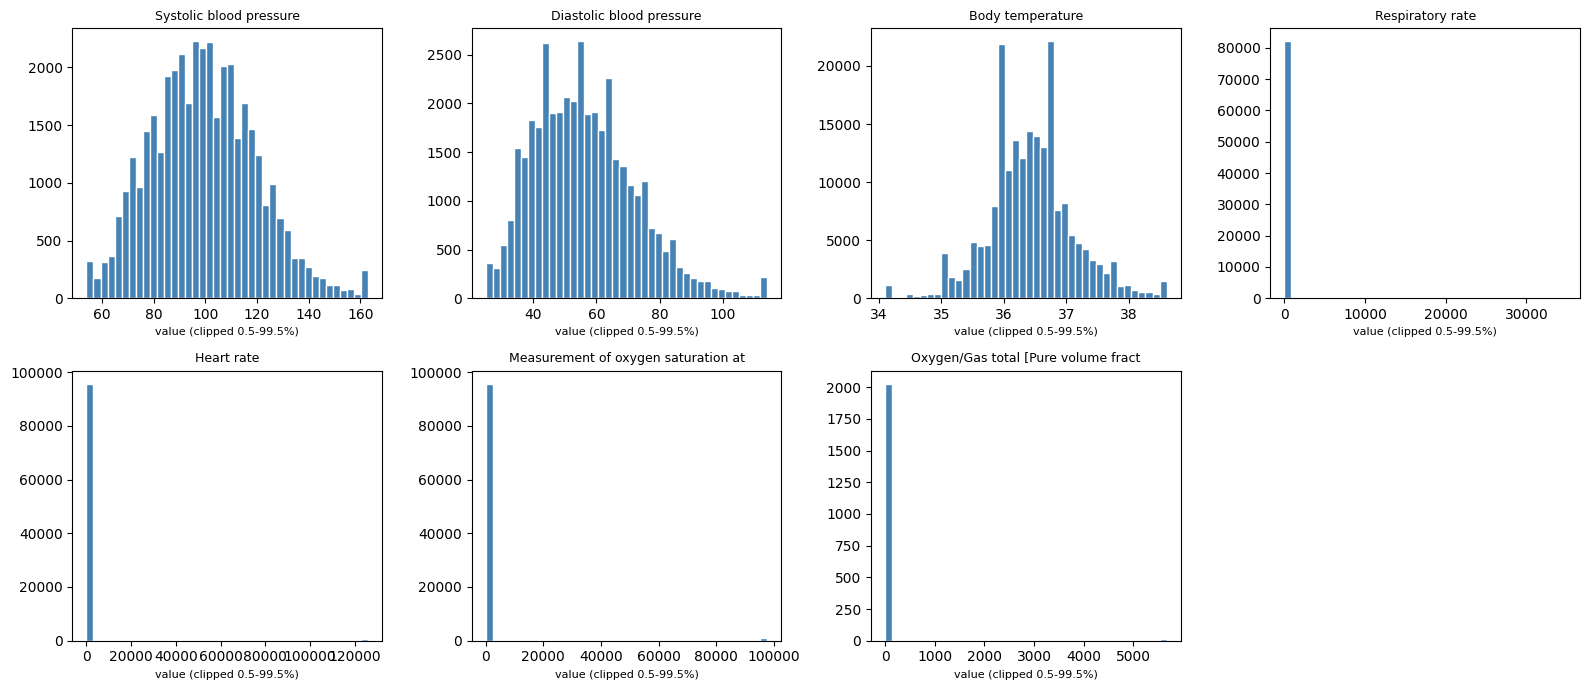

In [35]:
# Vitals: histograms of each vital sign (clipping extreme outliers for readability)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, vitals_cols):
    series = vitals[col].dropna()
    if len(series) == 0:
        ax.set_visible(False); continue
    lo, hi = series.quantile([0.005, 0.995])
    ax.hist(series.clip(lo, hi), bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col[:35], fontsize=9)
    ax.set_xlabel(f'value (clipped 0.5-99.5%)', fontsize=8)
# Hide leftover axes
for ax in axes.flat[len(vitals_cols):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

Plotting the 8 labs with lowest missingness:
['Chloride [Moles/volume] in Blood (0.52)', 'Sodium [Moles/volume] in Serum or Plasma (0.52)', 'Potassium [Moles/volume] in Blood (0.54)', 'Hematocrit [Volume Fraction] of Blood (0.59)', 'Blood arterial pH (0.60)', 'Creatinine [Mass/volume] in Blood (0.62)', ' activated (0.64)', 'Total white blood count (0.64)']



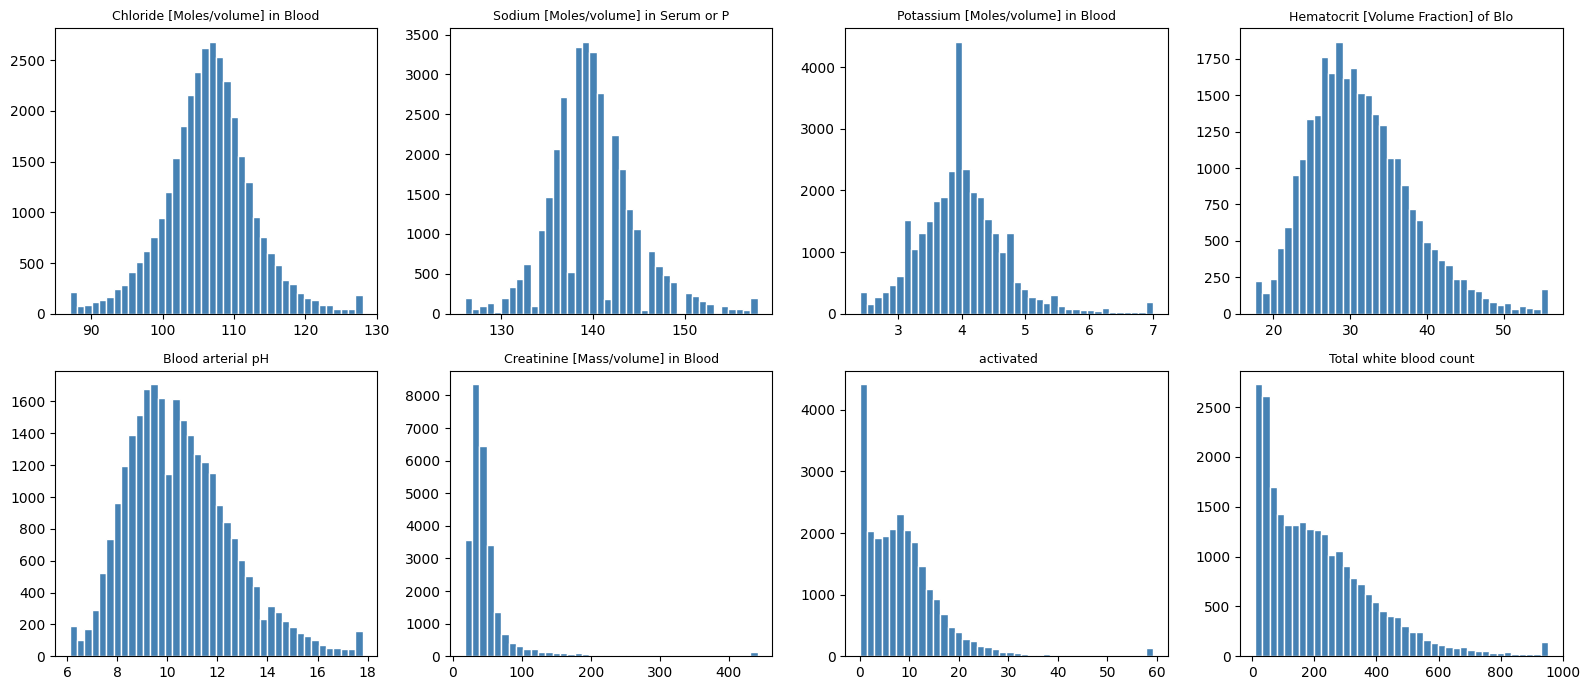

In [36]:
# Top 8 most-measured labs: histograms
top_labs = miss.head(8).index.tolist()
print('Plotting the 8 labs with lowest missingness:')
print([f'{c} ({miss[c]:.2f})' for c in top_labs])
print()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, top_labs):
    series = pd.to_numeric(labs[col], errors='coerce').dropna()
    if len(series) == 0:
        ax.set_visible(False); continue
    lo, hi = series.quantile([0.005, 0.995])
    ax.hist(series.clip(lo, hi), bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col[:35], fontsize=9)
plt.tight_layout(); plt.show()

In [37]:
# Vitals signal check: do septic and non-septic hours actually differ?
# CLIP outliers per the data-quality cell so means aren't dominated by sensor errors.
CLIP_RANGES = {
    'Heart rate':                                                    (30, 250),
    'Respiratory rate':                                              (5, 100),
    'Systolic blood pressure':                                       (30, 220),
    'Diastolic blood pressure':                                      (15, 150),
    'Body temperature':                                              (30, 43),
    'Measurement of oxygen saturation at periphery':                 (50, 100),
    'Oxygen/Gas total [Pure volume fraction] Inhaled gas':           (0.21, 1.0),
}

vitals_h = vitals.copy()
vitals_h['measurement_datetime'] = vitals_h['measurement_datetime'].dt.floor('h')
for col, (lo, hi) in CLIP_RANGES.items():
    if col in vitals_h.columns:
        vitals_h.loc[(vitals_h[col] < lo) | (vitals_h[col] > hi), col] = np.nan

vh = vitals_h.groupby(['person_id', 'measurement_datetime'], as_index=False)[vitals_cols].mean()
merged = y_train.merge(vh, on=['person_id', 'measurement_datetime'], how='left')

summary = pd.DataFrame({
    'mean_negative':   merged.loc[merged.SepsisLabel == 0, vitals_cols].mean(),
    'mean_positive':   merged.loc[merged.SepsisLabel == 1, vitals_cols].mean(),
    'median_negative': merged.loc[merged.SepsisLabel == 0, vitals_cols].median(),
    'median_positive': merged.loc[merged.SepsisLabel == 1, vitals_cols].median(),
}).round(2)
summary['mean_diff'] = (summary['mean_positive'] - summary['mean_negative']).round(2)
print('Vital sign comparison: septic (1) vs non-septic (0) hours  [outliers clipped]')
print(summary)
print()
print('Expected sepsis pattern: HR ↑, RR ↑, Temp ↑ or ↓ (extremes), SBP ↓ in shock')

Vital sign comparison: septic (1) vs non-septic (0) hours  [outliers clipped]
                                                    mean_negative  mean_positive  median_negative  median_positive  mean_diff
Systolic blood pressure                                     99.79          96.01            99.00            97.05      -3.78
Diastolic blood pressure                                    56.35          50.88            55.00            52.79      -5.47
Body temperature                                            36.43          36.54            36.40            36.55       0.11
Respiratory rate                                            32.29          32.11            31.21            33.00      -0.18
Heart rate                                                 119.14         123.14           120.03           123.05       4.00
Measurement of oxygen saturation at periphery               96.07          94.75            97.18            96.79      -1.32
Oxygen/Gas total [Pure volume fraction] 

In [38]:
# Same for the top-coverage labs
labs_h = labs.copy()
labs_h['measurement_datetime'] = labs_h['measurement_datetime'].dt.floor('h')
for c in top_labs:
    labs_h[c] = pd.to_numeric(labs_h[c], errors='coerce')
lh = labs_h.groupby(['person_id', 'measurement_datetime'], as_index=False)[top_labs].mean()

merged_l = y_train.merge(lh, on=['person_id', 'measurement_datetime'], how='left')
lab_summary = pd.DataFrame({
    'mean_negative': merged_l.loc[merged_l.SepsisLabel == 0, top_labs].mean(),
    'mean_positive': merged_l.loc[merged_l.SepsisLabel == 1, top_labs].mean(),
}).round(3)
lab_summary['mean_diff'] = (lab_summary['mean_positive'] - lab_summary['mean_negative']).round(3)
print('Top-8 labs comparison: septic (1) vs non-septic (0) hours')
print(lab_summary)

Top-8 labs comparison: septic (1) vs non-septic (0) hours
                                          mean_negative  mean_positive  mean_diff
Chloride [Moles/volume] in Blood                106.499        108.421      1.922
Sodium [Moles/volume] in Serum or Plasma        139.775        143.524      3.749
Potassium [Moles/volume] in Blood                 6.204         10.843      4.639
Hematocrit [Volume Fraction] of Blood            35.271         34.506     -0.765
Blood arterial pH                                10.734         11.566      0.832
Creatinine [Mass/volume] in Blood                53.150         72.492     19.342
 activated                                        9.079         13.257      4.178
Total white blood count                         214.372        143.168    -71.204


## 5. Sepsis timing patterns

Where in stays do positive labels concentrate? What does a septic patient's labeled timeline actually look like?

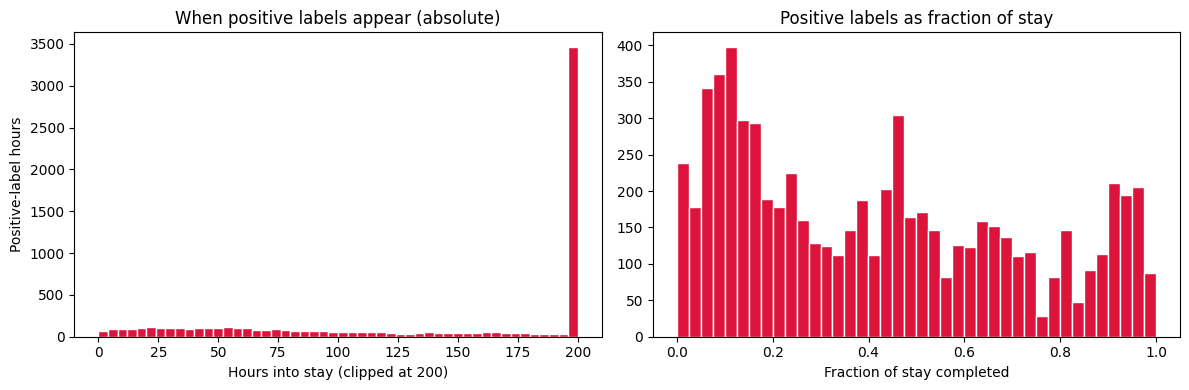

In [39]:
# Where in a stay do positive labels appear (absolute hours and as fraction of stay)?
y_pos = y_train_sorted[y_train_sorted.SepsisLabel == 1].copy()
y_pos['stay_length'] = y_pos.person_id.map(hours_per_pt)
y_pos['stay_fraction'] = y_pos['hour_index'] / y_pos['stay_length']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_pos['hour_index'].clip(upper=200), bins=50, color='crimson', edgecolor='white')
axes[0].set_xlabel('Hours into stay (clipped at 200)')
axes[0].set_ylabel('Positive-label hours')
axes[0].set_title('When positive labels appear (absolute)')

axes[1].hist(y_pos['stay_fraction'], bins=40, color='crimson', edgecolor='white')
axes[1].set_xlabel('Fraction of stay completed')
axes[1].set_title('Positive labels as fraction of stay')
plt.tight_layout(); plt.show()

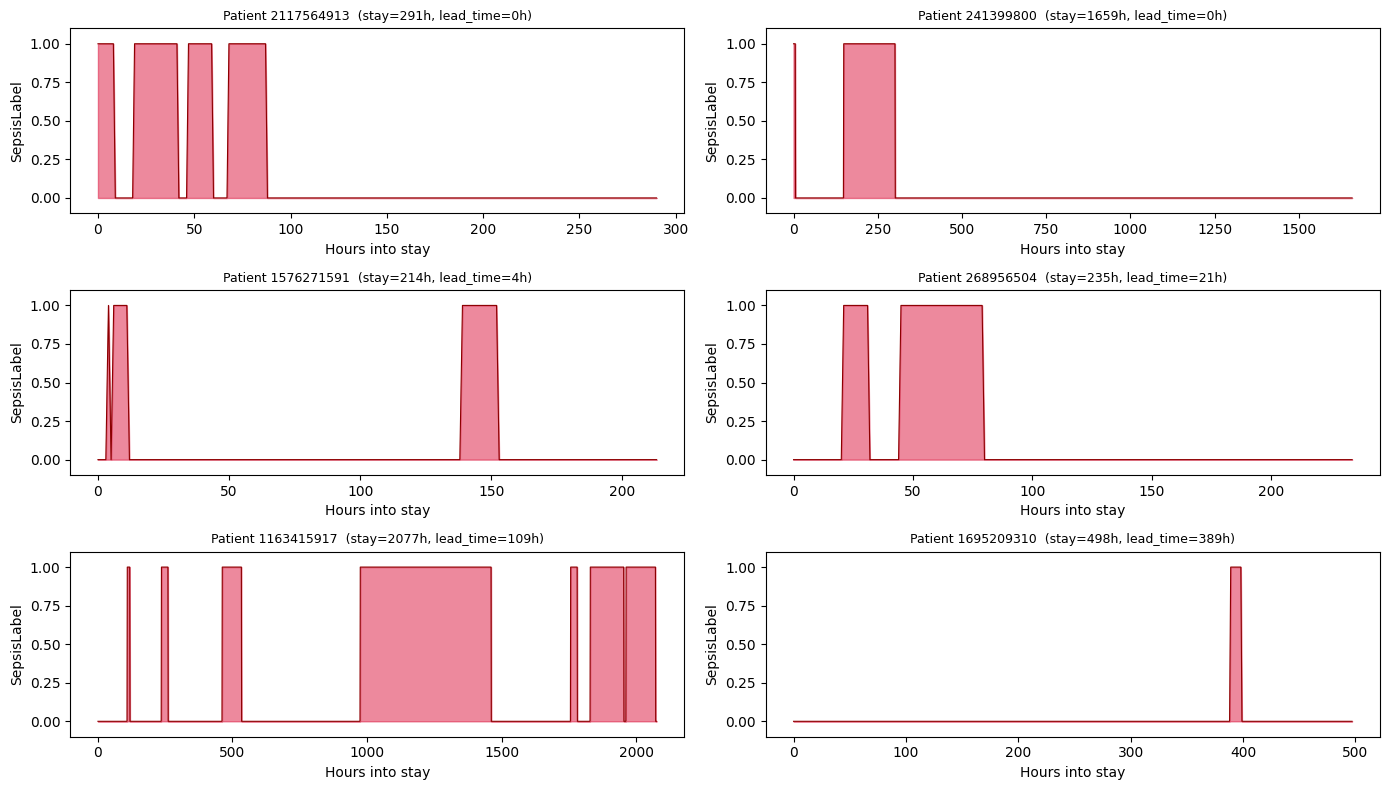

In [40]:
# Pick 6 example septic patients across the lead-time spectrum and plot their label timelines
sample_ids = (
    septic_pts.sort_values('lead_time')
              .iloc[[0, 5, 20, 40, 70, 90]]
              .index.tolist()
)

fig, axes = plt.subplots(3, 2, figsize=(14, 8))
for ax, pid in zip(axes.flat, sample_ids):
    d = y_train_sorted[y_train_sorted.person_id == pid]
    ax.fill_between(d['hour_index'], 0, d['SepsisLabel'], color='crimson', alpha=0.5)
    ax.plot(d['hour_index'], d['SepsisLabel'], color='darkred', linewidth=0.8)
    lt = septic_pts.loc[pid, 'lead_time']
    ax.set_title(f'Patient {pid}  (stay={len(d)}h, lead_time={lt:.0f}h)', fontsize=9)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlabel('Hours into stay'); ax.set_ylabel('SepsisLabel')
plt.tight_layout(); plt.show()

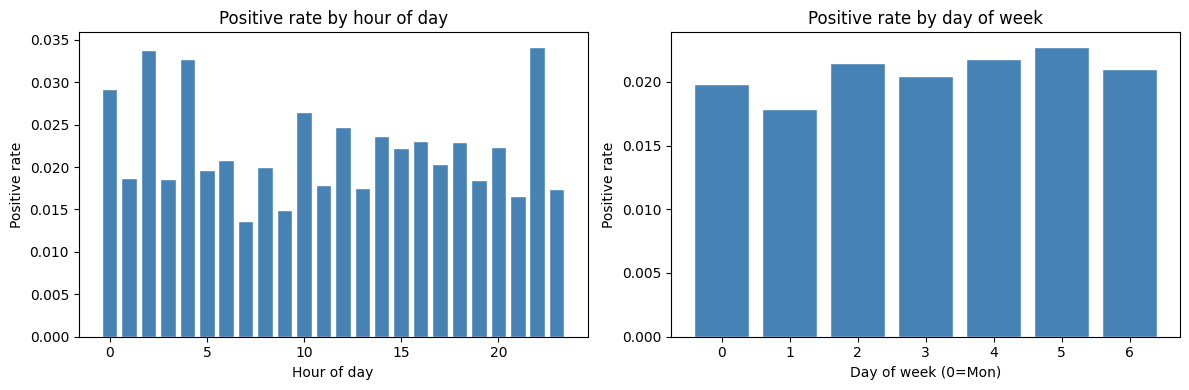

In [41]:
# Are positive labels concentrated at any time of day or day of week? (Could indicate labeling artifacts.)
y_train_sorted['hour_of_day'] = y_train_sorted['measurement_datetime'].dt.hour
y_train_sorted['day_of_week'] = y_train_sorted['measurement_datetime'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
by_hour = y_train_sorted.groupby('hour_of_day')['SepsisLabel'].mean()
by_day = y_train_sorted.groupby('day_of_week')['SepsisLabel'].mean()
axes[0].bar(by_hour.index, by_hour.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Hour of day'); axes[0].set_ylabel('Positive rate')
axes[0].set_title('Positive rate by hour of day')
axes[1].bar(by_day.index, by_day.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Day of week (0=Mon)'); axes[1].set_ylabel('Positive rate')
axes[1].set_title('Positive rate by day of week')
plt.tight_layout(); plt.show()

## 6. Train vs test consistency

If train and test populations look very different, our cross-validation scores won't predict the leaderboard. Check stay length, demographics, and date ranges.

In [42]:
hours_per_pt_te = y_test.groupby('person_id').size()
compare = pd.DataFrame({
    'train': hours_per_pt.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]),
    'test':  hours_per_pt_te.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]),
}).round(1)
print('Stay length per patient (hours):')
print(compare)

Stay length per patient (hours):
        train    test
count  2649.0  1138.0
mean    125.2   114.7
std     265.8   206.2
min       1.0     2.0
25%      27.0    27.0
50%      55.0    52.5
75%     125.0   124.8
90%     269.0   243.3
95%     450.0   358.1
99%    1106.6  1062.8
max    5792.0  2616.0


In [43]:
print('Gender (train):', demo_tr.gender.value_counts(normalize=True).round(3).to_dict())
print('Gender (test): ', demo_te.gender.value_counts(normalize=True).round(3).to_dict())
print()
print(f'Age in months — train: median={demo_tr.age_in_months.median():.0f}, mean={demo_tr.age_in_months.mean():.0f}')
print(f'Age in months — test:  median={demo_te.age_in_months.median():.0f}, mean={demo_te.age_in_months.mean():.0f}')
print()
print(f'Unique persons (train demo): {demo_tr.person_id.nunique():,}')
print(f'Unique persons (test demo):  {demo_te.person_id.nunique():,}')

Gender (train): {'MALE': 0.576, 'FEMALE': 0.424}
Gender (test):  {'MALE': 0.572, 'FEMALE': 0.428}

Age in months — train: median=43, mean=69
Age in months — test:  median=47, mean=70

Unique persons (train demo): 2,649
Unique persons (test demo):  1,142


In [44]:
print(f'Train date range: {y_train.measurement_datetime.min()}  ->  {y_train.measurement_datetime.max()}')
print(f'Test date range:  {y_test.measurement_datetime.min()}  ->  {y_test.measurement_datetime.max()}')
print()
print('Train year distribution:')
print(y_train.measurement_datetime.dt.year.value_counts().sort_index().to_string())
print()
print('Test year distribution:')
print(y_test.measurement_datetime.dt.year.value_counts().sort_index().to_string())

Train date range: 2018-12-23 16:00:00  ->  2025-01-10 10:00:00
Test date range:  2019-04-16 14:00:00  ->  2025-01-10 10:00:00

Train year distribution:
measurement_datetime
2018.0        3
2019.0    28293
2020.0    48144
2021.0    52201
2022.0    58545
2023.0    56561
2024.0    87579
2025.0      311

Test year distribution:
measurement_datetime
2019    10284
2020    15639
2021    20760
2022    22658
2023    23524
2024    37394
2025      224


## Summary of findings

Key things this EDA established (filled into `SPEC.md`):

- **Class imbalance**: 2.07% hour-level, 3.66% patient-level → use `scale_pos_weight`, drop SMOTE
- **Lead time bimodal**: 15 patients septic on arrival, 24 within 6h, 54 with ≥24h history → need short + long rolling windows
- **Coverage is sparse**: vitals 75%, devices/procedures ~55%, labs/drugs only 20% → forward-fill + time-since-last is essential
- **6 lab columns are >96% missing** → drop arterial blood gas panel, D-dimer, IL-6, ionised calcium, blood venous pH
- **Train/test patient-disjoint** → use `StratifiedGroupKFold(groups=person_id)` for CV
- **Event tables are low cardinality** (5 devices, 7 procedures, 50 drugs, 9 routes) → wide pivot is fine, no top-K cap needed there

**Two surprises uncovered during this run that the spec didn't anticipate:**

1. **Vitals contain extreme outliers** — SBP up to 138K, HR up to 215K. Almost certainly sensor errors / unit confusions. **Need a clipping step before training** (clinically plausible ranges in the data-quality cell). Untreated, these outliers will destroy any distance-based model and skew tree splits.
2. **`observation_train.csv` is NOT time-series** — it's a static per-visit admission-reason categorical (3 values: Médico / Quirúrgico-Electivo / Quirúrgico-Urgencia, exactly 1 concept name). The partner's `data_prep.load_observation_table` treats this as time-series with hourly pivot and top-K filter, which is wrong. **Should be merged once per visit as a categorical demographic feature.**